# Clasificación de Prestaciones Laborales con Regresión Logística

**Autor:** Arturo Vargas Espinosa

# Introducción, Planteamiento del Problema y Contexto

Este reporte construye y evalúa un modelo de clasificación para predecir si una persona ocupada en México cuenta con **prestaciones laborales** (aguinaldo, vacaciones pagadas, reparto de utilidades, etc.), a partir de sus características sociodemográficas y de su empleo, usando los microdatos de la Encuesta Nacional de Ocupación y Empleo (ENOE) del primer trimestre de 2026, levantada por el INEGI.

La ENOE incluye una variable de prestaciones laborales (`pre_asa`), que es una variable de interés real para el fenómeno laboral (la formalidad del empleo) y no un corte arbitrario sobre otra variable. Sin embargo, tal como viene codificada, `pre_asa` no se puede usar directamente como variable de respuesta binaria: mezcla, en una sola columna, a las personas para quienes la pregunta simplemente no aplica (porque son empleadores o trabajan por cuenta propia) con quienes sí debían responder pero no dieron una respuesta válida, junto con las dos categorías que sí interesan (con y sin prestaciones). Antes de poder usarla como variable de respuesta, entonces, hay que entender esta estructura y acotar correctamente la población de estudio, como se explica más adelante.


# Metodología

Este reporte combina tres bloques: **clasificación mediante regresión logística**, **evaluación de la calidad del modelo mediante validación cruzada**, e **inferencia estadística sobre los coeficientes** (significancia y multicolinealidad).

### De la regresión lineal a la regresión logística

En un problema de clasificación binaria la variable de respuesta Y solo toma los valores 0 o 1, así que una recta de regresión lineal no es adecuada: puede predecir valores fuera del rango [0, 1], que no se pueden interpretar como probabilidad. La **regresión logística** resuelve esto modelando la probabilidad de pertenecer a la clase positiva con la función sigmoide:

> P(Y=1 | X) = 1 / ( 1 + e^-(β₀ + β₁X₁ + β₂X₂ + ... + βₚXₚ) )

Los coeficientes β ya no se interpretan como cambios directos en Y, sino como cambios en el **log-odds** (logaritmo de la razón de momios) de pertenecer a la clase positiva. Por eso, para interpretar un coeficiente en términos más intuitivos se calcula e^β (exponencial del coeficiente), el **odds ratio**: cuánto se multiplican los momios de la clase positiva por cada unidad que aumenta esa variable, manteniendo el resto de las variables constantes.


### Desbalance de clases

Cuando una clase tiene muchas más observaciones que la otra, un modelo puede lograr una exactitud alta con solo predecir siempre la clase mayoritaria, sin aprender nada útil. Para mitigar esto se usa el parámetro `class_weight="balanced"` de `LogisticRegression`, que pondera la función de verosimilitud dándole más peso a las observaciones de la clase minoritaria durante el ajuste, de modo que el modelo no las ignore.

Una decisión metodológica importante de este reporte: el modelo de `scikit-learn` con `class_weight="balanced"` es el que se usa para **predecir** (es el que se evalúa con validación cruzada, matriz de confusión, ROC/AUC, etc.), porque para ese propósito interesa que el modelo no ignore a la clase con menos cosas. Sin embargo, para inferencia estadística (calcular errores estándar y p-values correctos) se ajusta un segundo modelo, equivalente pero sin considerar las clases, usando `statsmodels`.



# Resumen de dataset


Antes de entrar a la definición del problema de clasificación, vale la pena describir el archivo completo, tal como llega, para tener claro con qué se está trabajando.

Se va a trabajar con la base de datos de enoe_2026_1t_limpio.csv

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Datos/enoe_2026_1t_limpio.csv', low_memory=False)
df.head(10)

,r_def,cve_ent,con,upm,n_pro_viv,v_sel,n_hog,h_mud,n_ren,c_res,...,tue1,pre_asa,niv_ins,anios_esc,hrsocup,ingocup,imssissste,emp_ppal,p6c,p6d
0,0,9,40006,906681,117,5,1,0,1,1,...,2,1,3,11,50,10000,1,2,,1
1,0,9,40018,912598,63,3,1,0,5,1,...,3,2,4,12,30,12900,4,1,,6
2,0,9,40018,912598,81,4,1,0,3,1,...,2,1,4,15,40,10000,2,2,,3
3,0,9,40039,922769,109,5,1,0,2,1,...,3,0,4,12,40,12900,4,1,,6
4,0,9,40040,911404,7,2,1,0,1,1,...,1,2,2,9,15,9000,4,1,,6
5,0,9,40046,901679,89,4,1,0,1,1,...,1,0,4,18,33,103200,4,2,,6
6,0,9,40051,905367,90,3,1,0,1,1,...,1,0,4,16,15,40000,4,2,,6
7,0,9,40051,905367,136,5,1,0,1,1,...,1,2,4,12,12,4300,4,1,,6
8,0,9,40062,916613,4,1,1,0,2,1,...,1,1,4,12,56,15050,1,2,,1
9,0,9,40064,916869,76,1,1,0,1,1,...,1,1,4,16,40,50000,1,2,,1


In [2]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126226 entries, 0 to 126225
Data columns (total 30 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   r_def       126226 non-null  int64 
 1   cve_ent     126226 non-null  int64 
 2   con         126226 non-null  int64 
 3   upm         126226 non-null  int64 
 4   n_pro_viv   126226 non-null  int64 
 5   v_sel       126226 non-null  int64 
 6   n_hog       126226 non-null  int64 
 7   h_mud       126226 non-null  int64 
 8   n_ren       126226 non-null  int64 
 9   c_res       126226 non-null  int64 
 10  sex         126226 non-null  int64 
 11  eda         126226 non-null  int64 
 12  n_hij       126226 non-null  object
 13  e_con       126226 non-null  int64 
 14  ur          126226 non-null  int64 
 15  zona        126226 non-null  int64 
 16  pos_ocu     126226 non-null  int64 
 17  seg_soc     126226 non-null  int64 
 18  rama_est1   126226 non-null  int64 
 19  ambito2     126226 non-

El archivo tiene 126,226 observaciones y 30 columnas. Casi todas las columnas se leen como `int64`, incluidas varias que en realidad son cualitativas (`sex`, `pos_ocu`, `e_con`, rama_est1, `ambito2`, `tue1`, `niv_ins`, `imssissste`, entre otras): son categorías codificadas con números, no cantidades. De las 30 columnas:

- **10 son identificadores de la encuesta** (`r_def`, `cve_ent`, `con`, `upm`, `n_pro_viv`, `v_sel`, `n_hog`, `h_mud`, `n_ren`, `c_res`): llaves y banderas de control del levantamiento, sin información sobre el fenómeno de interés. Se eliminan en la sección de limpieza.
- **2 tienen problemas de tipo de dato** (`p6c`, `n_hij`): `p6c` viene completamente vacía y `n_hij` representa una potencial fuga de datos, así que ambas se descartan.
- El resto son las variables sociodemográficas y laborales (sexo, edad, estado civil, escolaridad, horas trabajadas, ingreso, sector, tipo de unidad económica, acceso a seguridad social, formalidad, etc.), más `pre_asa`, que es la que se usa en este reporte para construir la variable de respuesta.

En las siguientes secciones se define la variable de respuesta y se limpian los datos.


# Definición del problema de clasificación

La variable que vamos a usar es **pre_asa**

La base de datos contiene la variable `pre_asa` (prestaciones laborales), con los siguientes códigos:

| Código | Significado |
|---|---|
| 0 | No aplica |
| 1 | Con prestaciones |
| 2 | Sin prestaciones |
| 3 | No especificado |

Antes de usarla como variable de respuesta conviene entender por qué existe el código "No aplica". La pregunta de prestaciones (aguinaldo, vacaciones pagadas, etc.) solo tiene sentido para alguien que trabaja *para alguien más* a cambio de un sueldo; a un empleador o a alguien que trabaja por su cuenta (`pos_ocu` = 2 o 3) no tiene prestaciones porque esa persona es su propio jefe. Se confirma esto cruzando `pos_ocu` contra `pre_asa`:

Diccionario de variables

En el diccionario de datos original de la ENOE, la fila de `pre_asa` se ve así:

| Variable | Tipo | Descripción |
|---|---|---|
| `pre_asa` | Cualitativa | Prestaciones, 0 - No aplica, 1 - Con Prestaciones, 2 - Sin Prestaciones, 3 - No especificado |

Tal cual, esta variable **no se puede usar directamente** como variable de respuesta binaria: mezcla en una sola columna dos cosas distintas, personas a las que la pregunta simplemente no les aplica (código 0, porque son empleadores o trabajan por cuenta propia) y personas a las que sí les aplica pero no se obtuvo una respuesta válida (código 3), junto con las dos categorías que sí interesan (1 y 2). Usarla tal como está no tendría sentido para un problema binario.

Filtrando esas dos categorías (0 y 3), es decir, quedándose solo con las observaciones donde `pre_asa` no está vacía en el sentido relevante (personas empleadas con jefe y que tienen nómina que sí respondieron 1 o 2), la variable sí se vuelve usable. Así queda la entrada equivalente del diccionario para la variable que realmente entra al modelo:

| Variable | Tipo | Descripción |
|---|---|---|
| `TienePrestaciones` (derivada de `pre_asa`, tras excluir 0 y 3) | Cualitativa binaria (0/1) | 1 - Con prestaciones (`pre_asa` = 1); 0 - Sin prestaciones (`pre_asa` = 2). Definida únicamente sobre personas ocupadas subordinadas y remuneradas (`pos_ocu` = 1) con respuesta válida de prestaciones |

Esta es la variable de respuesta que efectivamente se usa a lo largo de todo el reporte (ver definición formal más abajo).

In [3]:
pd.crosstab(df['pos_ocu'], df['pre_asa'])

pre_asa,0,1,2,3
pos_ocu,,,,
1,0,65490,28250,458
2,5872,0,0,0
3,26156,0,0,0


Esto confirma lo esperado: el código 0 (no aplica) coincide exactamente con los empleadores (**pos_ocu**=2) y los trabajadores por cuenta propia (**pos_ocu**=3). Es decir, solo a las personas subordinadas se les preguntó si tienen prestaciones.

**Definición de la variable de respuesta:** se acota la población de estudio a personas ocupadas subordinadas y remuneradas (`pos_ocu` = 1), y dentro de ese grupo se descartan las 458 observaciones con `pre_asa` = 3 (no especificado). Con esto se define la variable binaria:

**TienePrestaciones** = 1  si `pre_asa` = 1 (con prestaciones) **TienePrestaciones** = 0  si `pre_asa` = 2 (sin prestaciones)

Es importante notar que **`pos_ocu` deja de ser una variable explicativa útil** en este análisis: al acotar la población a `pos_ocu` = 1, esa columna se vuelve constante para todas las observaciones, así que se elimina del conjunto de variables predictoras.

## Relevancia de la variable

Las prestaciones laborales son uno de los indicadores más usados por el INEGI y en la literatura de economía laboral para medir la **formalidad del empleo**. Que una persona cuente con aguinaldo y vacaciones pagadas no es un beneficio menor: en México se asocia directamente con el acceso a seguridad social, con la estabilidad del empleo y, de forma bien documentada en la literatura de economía laboral, con mejores condiciones salariales.

Con esto se hace un sub dataset quitando a los que trabajan por su cuenta o son empleadores, dejando solo a los subordinados con respuesta válida en prestaciones. Luego se crea TienePrestaciones a partir de pre_asa, y se cuenta cuántos quedaron en cada clase para ver el balance.

In [4]:
sub_pobl = df[(df['pos_ocu'] == 1) & (df['pre_asa'].isin([1, 2]))].copy()
print("Observaciones tras delimitar la poblacion:", sub_pobl.shape)

sub_pobl['TienePrestaciones'] = (sub_pobl['pre_asa'] == 1).astype(int)

conteo = sub_pobl['TienePrestaciones'].value_counts()
prop = sub_pobl['TienePrestaciones'].value_counts(normalize=True)
print("\nConteo de clases:")
print(conteo)
print("\nProporcion de clases:")
print(prop.round(4))

Observaciones tras delimitar la poblacion: (93740, 30)

Conteo de clases:
TienePrestaciones
1    65490
0    28250
Name: count, dtype: int64

Proporcion de clases:
TienePrestaciones
1    0.6986
0    0.3014
Name: proportion, dtype: float64


Ahora tenemos que las personas que tienen prestaciones son 65490 y las personas que no tienen prestaciones son 28250

Ahora lo vamos a graficar con matplotlib para ver esta información de manera visual

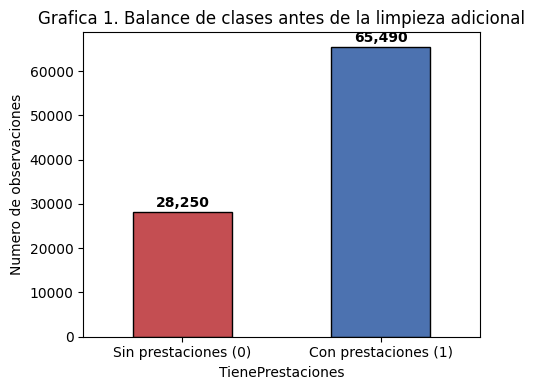

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
conteo.sort_index().plot(kind='bar', color=['#C44E52', '#4C72B0'], edgecolor='black', ax=ax)
ax.set_xticklabels(['Sin prestaciones (0)', 'Con prestaciones (1)'], rotation=0)
ax.set_ylabel('Numero de observaciones')
ax.set_title('Grafica 1. Balance de clases antes de la limpieza adicional')
for i, v in enumerate(conteo.sort_index()):
    ax.text(i, v + 1000, f"{v:,}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Preparación y limpieza de datos

En esta sección se limpian los datos antes de ajustar la regresión logística.

Primero se eliminan las columnas que son identificadores de la encuesta (llave primaria y banderas de control), que no aportan información sobre el fenómeno, y las columnas `p6c` y `n_hij`, que vienen vacía/estructuralmente faltante y representan una potencial fuga de datos, respectivamente.


In [6]:
ids = ['r_def', 'c_res', 'cve_ent', 'con', 'upm', 'n_pro_viv',
       'v_sel', 'n_hog', 'h_mud', 'n_ren']
sub_pobl = sub_pobl.drop(columns=ids)
sub_pobl = sub_pobl.drop(columns=['p6c', 'n_hij'])
print(sub_pobl.shape)

(93740, 19)


Con este cambio ahora quedan 93740 observaciónes y las columnas bajan de 30 a 19

Varias variables cualitativas tienen un código de "no especificado" (o equivalente) que no representa una categoría real y que conviene eliminar por ser pocos casos frente al tamaño de la muestra: `anios_esc` = 99, `e_con` = 9, `rama_est1` = 4, `tue1` = 4 y `niv_ins` = 5.


In [7]:
print("anios_esc == 99:", (sub_pobl['anios_esc'] == 99).sum())
print("e_con == 9:        ", (sub_pobl['e_con'] == 9).sum())
print("rama_est1 == 4:    ", (sub_pobl['rama_est1'] == 4).sum())
print("tue1 == 4:         ", (sub_pobl['tue1'] == 4).sum())
print("niv_ins == 5:      ", (sub_pobl['niv_ins'] == 5).sum())

sub_pobl['anios_esc'] = sub_pobl['anios_esc'].replace(99, np.nan)
sub_pobl = sub_pobl.dropna(subset=['anios_esc'])
sub_pobl = sub_pobl[sub_pobl['e_con'] != 9]
sub_pobl = sub_pobl[sub_pobl['rama_est1'] != 4]
sub_pobl = sub_pobl[sub_pobl['tue1'] != 4]
sub_pobl = sub_pobl[sub_pobl['niv_ins'] != 5]
print("\nShape tras quitar codigos de no especificado:", sub_pobl.shape)

anios_esc == 99: 236
e_con == 9:         11
rama_est1 == 4:     494
tue1 == 4:          478
niv_ins == 5:       179

Shape tras quitar codigos de no especificado: (92975, 19)


Con estos cambios las observaciones bajan de 93740 a 92975

También se eliminan los valores atípicos de horas trabajadas, con el mismo criterio usado en el proyecto de [regresión del ingreso laboral con la ENOE](../regresion-caso-real-enoe/README.md).
Para `hrsocup` (horas trabajadas a la semana) se aplica un criterio similar: se eliminan las observaciones con más de 119 horas semanales (jornadas físicamente inconsistentes) y las que reportan 0 horas trabajadas pese a estar ocupadas (caso contradictorio, no una jornada real).


In [8]:
print("hrsocup >= 119:", (sub_pobl['hrsocup'] >= 119).sum())
sub_pobl = sub_pobl[sub_pobl['hrsocup'] <= 119]

print("hrsocup == 0:", (sub_pobl['hrsocup'] == 0).sum())
sub_pobl = sub_pobl[sub_pobl['hrsocup'] != 0]

print("\nShape final tras limpieza:", sub_pobl.shape)

hrsocup >= 119: 17
hrsocup == 0: 3862

Shape final tras limpieza: (89100, 19)


Despues de esta limpia se quitan casi 4 mil observaciones y baja a ser 89100 observaciones

### Eliminación de variables redundantes con la variable de respuesta

Antes de seleccionar las variables explicativas finales hay que revisar la colinealidad de `pre_asa`/`TienePrestaciones` con otras variables de la base. El riesgo aquí es que algunas variables midan **casi lo mismo que la variable de respuesta** (fuga de datos), lo cual invalidaria la variable de respuesta, entonces que identificar y eliminar

Ahora vamos a sacar la matriz de correlación completa de las 19 variables que tenemos en `sub_pobl` hasta este punto (incluyendo `TienePrestaciones`), para ver de un vistazo cuáles se relacionan demasiado con la variable de respuesta (fuga de datos) y cuáles miden básicamente lo mismo entre sí (redundancia).


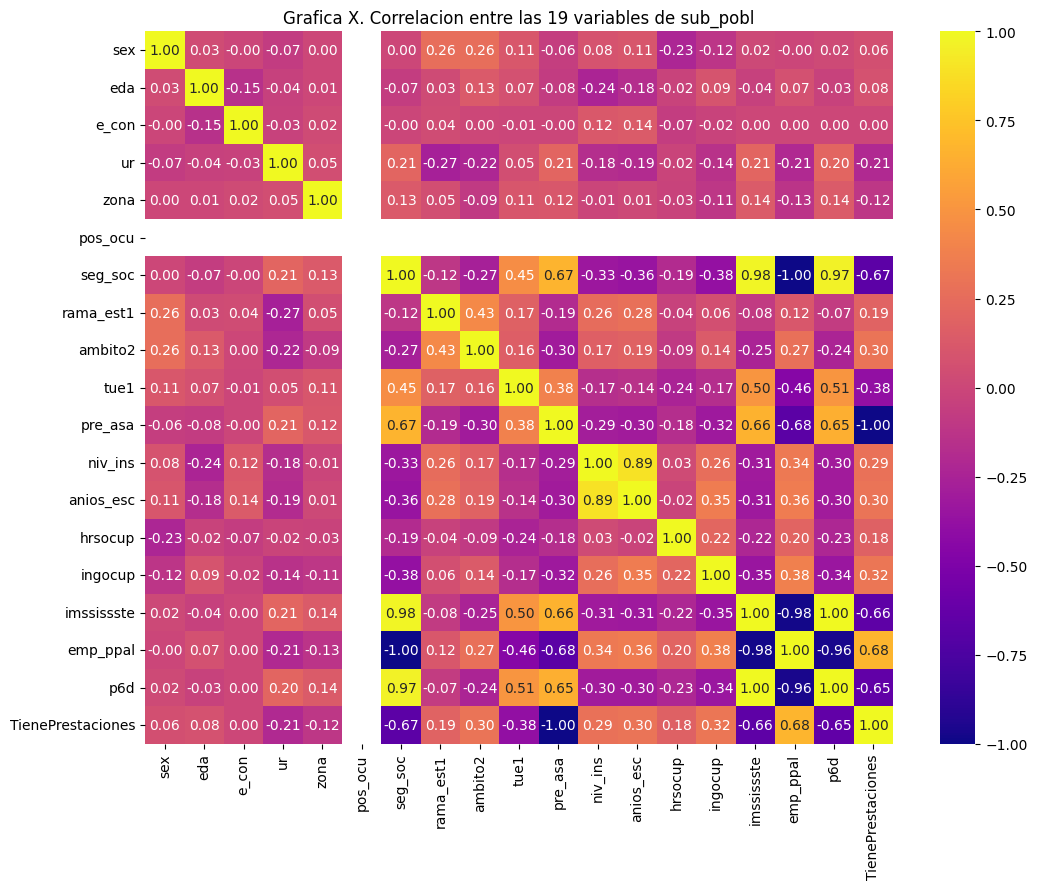

In [9]:
from seaborn import heatmap

corr_sub_pobl = sub_pobl.corr()

plt.figure(figsize=(11, 9))
heatmap(corr_sub_pobl, annot=True, fmt=".2f", cmap="plasma", vmin=-1, vmax=1)
plt.title("Grafica 2. Correlacion entre las 19 variables de sub_pobl")
plt.tight_layout()
plt.show()

Viendo la matriz, vamos a quitar `pos_ocu`, `pre_asa`, `emp_ppal`, `seg_soc`, `imssissste`, `p6d` y `niv_ins`:

- `pos_ocu` y `pre_asa` ya no aportan nada: `pos_ocu` quedó fija en 1 desde que acotamos la población, y `pre_asa` es literalmente de donde salió `TienePrestaciones`, así que dejarla sería fuga de datos garantizada (100% correlación con la respuesta).
- `emp_ppal` y `seg_soc` están fuertemente correlacionadas con `TienePrestaciones`: la definición de "empleo formal" del INEGI ya incluye tener prestaciones, así que el modelo estaría aprendiendo la definición, no un patrón nuevo.
- `imssissste` y `p6d` se mueven prácticamente igual entre sí (correlación de 0.997): son casi la misma pregunta hecha dos veces.
- `niv_ins` se mueve casi igual que `anios_esc` (correlación de 0.895): ambas miden escolaridad, así que basta con quedarnos con una.

Con esto pasamos de 19 columnas a 12 (11 variables explicativas + `TienePrestaciones`).

In [10]:
drop_cols = ['pos_ocu', 'pre_asa', 'emp_ppal', 'seg_soc', 'imssissste', 'p6d', 'niv_ins']
datos = sub_pobl.drop(columns=drop_cols)

print("Variables finales:", list(datos.columns))
print("Shape:", datos.shape)

Variables finales: ['sex', 'eda', 'e_con', 'ur', 'zona', 'rama_est1', 'ambito2', 'tue1', 'anios_esc', 'hrsocup', 'ingocup', 'TienePrestaciones']
Shape: (89100, 12)


Con estas columnas eliminadas tenemos 89100 observaciones, 12 columnas, con una siendo TienePrestaciones y las demas siendo variables para ayudar al entrenamiento del resultado

# Separación de datos y balance de clases

Ahora vamos a dividir el dataset a train (80) y test (20) con el train_test_split. Con esto vamos a usar scikitlearn para poner un balance.

Un balance nos ayuda para poder garantizar la proporcion de clases entre ambos subconjuntos, porque puedes tener un 80 a 20, pero todos los negativos se queden en el 80, entonces eso no nos ayuda. `stratify` obliga a que la partición aleatoria se haga *dentro de cada clase por separado*, preservando la proporción original tanto en entrenamiento como en prueba.

In [11]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    datos, train_size=0.8, random_state=67,
    stratify=datos['TienePrestaciones']
)

print("Entrenamiento:", train.shape)
print("Prueba:       ", test.shape)

balance = pd.DataFrame({
    'Original': datos['TienePrestaciones'].value_counts(normalize=True),
    'Entrenamiento': train['TienePrestaciones'].value_counts(normalize=True),
    'Prueba': test['TienePrestaciones'].value_counts(normalize=True)
}).round(4)
print("\nProporcion de clases por subconjunto:")
print(balance)

Entrenamiento: (71280, 12)
Prueba:        (17820, 12)

Proporcion de clases por subconjunto:
                   Original  Entrenamiento  Prueba
TienePrestaciones                                 
1                    0.6947         0.6947  0.6947
0                    0.3053         0.3053  0.3053


Aqui podemos ver que el balance esta correcto en el train y test

Aqui podemos ver que si se aplico bien el balance porque las clases son casi identicas que en los datos originales, en entrenamiento y en prueba (69.47% con prestaciones / 30.53% sin prestaciones en los tres casos)

### Validación
Ahora vamos a comprobar con números que el `stratify` sí funcionó, y no solo viéndolo "a ojo" en la tabla de arriba. Para eso comparamos los conteos reales de cada clase en train y test con una prueba ji-cuadrada.

In [12]:
from scipy.stats import chi2_contingency

conteos_split = pd.DataFrame({
    'Entrenamiento': train['TienePrestaciones'].value_counts().sort_index(),
    'Prueba': test['TienePrestaciones'].value_counts().sort_index()
})
conteos_split.index = ['Sin prestaciones (0)', 'Con prestaciones (1)']
print(conteos_split)

chi2, p_valor, dof, esperado = chi2_contingency(conteos_split.T)
print(f"\nchi2 = {chi2:.4f}")
print(f"p-value = {p_valor:.4f}")

                      Entrenamiento  Prueba
Sin prestaciones (0)          21762    5441
Con prestaciones (1)          49518   12379

chi2 = 0.0000
p-value = 1.0000


El p-value sale 1.0000, es decir, no hay evidencia de que la clase de alguien dependa de si cayó en entrenamiento o en prueba: el balance quedó igual en ambos. Esto importa porque si train y test tuvieran proporciones distintas, cualquier diferencia que veamos después entre las métricas de validación cruzada y las de prueba podría deberse solo a eso, no a que el modelo generalice bien o mal.


Ahora vamos a hacer las ultimas codificaciones con dummies antes de seguir con la evaluación cruzada

Se recodifican las variables binarias (`sex`, `ur`, `zona`) a 0/1, y se generan variables *dummy* para las variables cualitativas con más de dos categorías (`e_con`, `rama_est1`, `ambito2`, `tue1`), usando `drop_first=True` para evitar colinealidad perfecta entre las dummies. La codificación se hace por separado en `train` y `test`, así que se verifica al final que ambos subconjuntos terminen con exactamente las mismas columnas.

In [13]:
train = train.copy()
test = test.copy()

for d in (train, test):
    d['sex'] = d['sex'].replace({1: 0, 2: 1})
    d['ur'] = d['ur'].replace({1: 0, 2: 1})
    d['zona'] = d['zona'].replace({1: 0, 2: 1})

cat_multi = ['e_con', 'rama_est1', 'ambito2', 'tue1']
train = pd.get_dummies(train, columns=cat_multi, drop_first=True)
test = pd.get_dummies(test, columns=cat_multi, drop_first=True)

for d in (train, test):
    for col in d.columns:
        if d[col].dtype == bool:
            d[col] = d[col].astype(int)

print("Columnas en train pero no en test:", set(train.columns) - set(test.columns))
print("Columnas en test pero no en train:", set(test.columns) - set(train.columns))

X_train = train.drop(columns=['TienePrestaciones'])
Y_train = train['TienePrestaciones']
X_test = test.drop(columns=['TienePrestaciones'])
Y_test = test['TienePrestaciones']

print("\nX_train:", X_train.shape, " X_test:", X_test.shape)
print("Variables explicativas finales (con dummies):")
print(list(X_train.columns))

Columnas en train pero no en test: set()
Columnas en test pero no en train: set()

X_train: (71280, 23)  X_test: (17820, 23)
Variables explicativas finales (con dummies):
['sex', 'eda', 'ur', 'zona', 'anios_esc', 'hrsocup', 'ingocup', 'e_con_2', 'e_con_3', 'e_con_4', 'e_con_5', 'e_con_6', 'rama_est1_2', 'rama_est1_3', 'ambito2_2', 'ambito2_3', 'ambito2_4', 'ambito2_5', 'ambito2_6', 'ambito2_7', 'ambito2_8', 'tue1_2', 'tue1_3']


Aqui podemos ver que ahora las columnas son 23 ambos en train y en test

# Evaluación mediante validación cruzada

Usando únicamente los datos de entrenamiento (`X_train`, `Y_train`), se estima el desempeño esperado del modelo con **validación cruzada de 7 folds** (`StratifiedKFold`, que además conserva la proporción de clases dentro de cada fold). En cada una de las 7 iteraciones se entrena una regresión logística (con `class_weight="balanced"` para compensar el desbalance de clases) sobre 6 folds y se evalúa en el fold restante, calculando exactitud, precisión, sensibilidad, F1 y AUC.

(Se usa el solver `newton-cg` en vez del `lbfgs` por defecto porque, al no reescalar variables como `ingocup` y `hrsocup` —que están en escalas muy distintas a las variables dummy 0/1—, `lbfgs` no siempre converge en el número de iteraciones por defecto; `newton-cg` converge sin problema y mantiene los coeficientes en las unidades originales, lo cual facilita su interpretación más adelante.)

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

modelo_cv = LogisticRegression(max_iter=1251, class_weight='balanced', solver='newton-cg')

skf = StratifiedKFold(n_splits=7, shuffle=True, random_state=67)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_resultados = cross_validate(modelo_cv, X_train, Y_train, cv=skf, scoring=scoring)

resumen_cv = pd.DataFrame({
    metrica: [cv_resultados['test_' + metrica].mean(), cv_resultados['test_' + metrica].std()]
    for metrica in scoring
}, index=['media', 'desv_estandar']).T

print("Metricas por fold:")
for metrica in scoring:
    print(f"  {metrica:10s}: {np.round(cv_resultados['test_' + metrica], 4)}")

print("\nResumen (media +/- desviacion estandar):")
print(resumen_cv.round(4))

Metricas por fold:
  accuracy  : [0.8147 0.8171 0.8164 0.818  0.8152 0.8173 0.8146]
  precision : [0.914  0.9127 0.9117 0.9147 0.9114 0.9125 0.9117]
  recall    : [0.8094 0.8147 0.8145 0.814  0.813  0.8152 0.8117]
  f1        : [0.8585 0.8609 0.8604 0.8614 0.8594 0.8611 0.8588]
  roc_auc   : [0.8874 0.8917 0.8898 0.8934 0.8906 0.89   0.8908]

Resumen (media +/- desviacion estandar):
            media  desv_estandar
accuracy   0.8162         0.0013
precision  0.9127         0.0011
recall     0.8132         0.0019
f1         0.8601         0.0011
roc_auc    0.8905         0.0017


Los resultados son consistentes entre folds: la desviación estándar de cada métrica es muy chica (entre 0.0011 y 0.0019), lo que indica que el desempeño del modelo no depende fuertemente de qué observaciones específicas cayeron en cada fold. En promedio, el modelo alcanza una **exactitud de 81.6%**, una **precisión de 91.3%** (cuando predice que alguien tiene prestaciones, acierta 9 de cada 10 veces), una **sensibilidad de 81.3%** (detecta 8 de cada 10 personas que sí tienen prestaciones) y un **AUC de 0.89**, que ya sugiere una buena capacidad discriminativa del modelo (más adelante se interpreta con más detalle junto con la curva ROC).

Esto es más confiable que evaluar el modelo con un solo fold del train-test, porque el 81.6% de exactitud es el promedio de 7 pruebas distintas, no el resultado de una sola división que por suerte (o mala suerte) pudo haber salido mejor o peor. Nos da una idea más realista de qué tan bien va a funcionar el modelo antes de probarlo con el conjunto de test

# Entrenamiento final y evaluación en prueba

Se entrena ahora el modelo final usando la **totalidad** del conjunto de entrenamiento (no solo 6 de los 7 folds), y se evalúa su desempeño en el conjunto de prueba, que hasta este momento no se había tocado en ningún análisis.

Se jugo con muchos umbrales dentro de este modelo y se escogio el umbral de 0.6, primero se intento con 0.4 y podiamos ver que le atinaba más a las personas con prestaciones que a las de sin prestaciones, entonces decidi cambiar al umbral de 0.6 para que tenga más correctas dentro de las personas sin prestaciones, que esas personas es mejor saber si cuentan con un trabajo formal o no, entonces es más importante fijarse en que prediga la gente sin prestaciones, no se subio más de 0.6 porque luego el error de con prestaciones si subia bastante.

Modelo entrenado con 71280 observaciones.


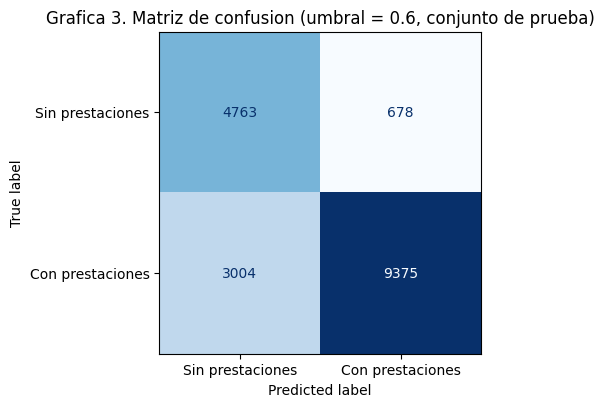

[[4763  678]
 [3004 9375]]


In [25]:
modelo = LogisticRegression(max_iter=1000, class_weight='balanced', solver='newton-cg')
modelo.fit(X_train, Y_train)

probs_test = modelo.predict_proba(X_test)[:, 1]

umbral = 0.6
pred_test = (probs_test >= umbral).astype(int)

print("Modelo entrenado con", X_train.shape[0], "observaciones.")
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

cm = confusion_matrix(Y_test, pred_test)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=['Sin prestaciones', 'Con prestaciones']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Grafica 3. Matriz de confusion (umbral = 0.6, conjunto de prueba)')
plt.tight_layout()
plt.show()

print(cm)

La diagonal principal (4,763 verdaderos sin prestaciones + 9,375 verdaderos con prestaciones) concentra la gran mayoría de las 17,820 observaciones de prueba. Fuera de la diagonal: 678 personas sin prestaciones fueron clasificadas incorrectamente como si las tuvieran (falsos positivos), y 3,004 personas con prestaciones fueron clasificadas incorrectamente como si no las tuvieran (falsos negativos). El modelo comete bastantes más errores de falso negativo que de falso positivo, justo el efecto esperado de haber subido el umbral a 0.6: al exigirle más probabilidad para etiquetar a alguien como "con prestaciones", el modelo se vuelve más conservador con esa clase, así que se le escapan más personas que sí tienen prestaciones (falsos negativos suben de 2,391 a 3,004 frente al umbral de 0.5), a cambio de equivocarse menos con quienes no las tienen (falsos positivos bajan de 920 a 678) — que es exactamente el intercambio que se buscaba al priorizar detectar correctamente a la gente sin prestaciones.

In [26]:
acc = accuracy_score(Y_test, pred_test)
prec = precision_score(Y_test, pred_test)
rec = recall_score(Y_test, pred_test)
f1 = f1_score(Y_test, pred_test)
auc = roc_auc_score(Y_test, probs_test)

print(f"Exactitud (accuracy): {acc:.4f}")
print(f"Precision:            {prec:.4f}")
print(f"Sensibilidad (recall):{rec:.4f}")
print(f"F1-score:             {f1:.4f}")
print(f"AUC:                  {auc:.4f}")

Exactitud (accuracy): 0.7934
Precision:            0.9326
Sensibilidad (recall):0.7573
F1-score:             0.8359
AUC:                  0.8908


Con el umbral de 0.6, el modelo alcanza una exactitud de 79.3%, una precisión de 93.3% (cuando predice "con prestaciones", casi nunca se equivoca), una sensibilidad de 75.7% (deja escapar 1 de cada 4 personas que sí tienen prestaciones, el costo de haber subido el umbral) y un AUC de 0.891, idéntico al de antes porque el AUC no cambia con el punto de corte que elijas.

## Comparación validación cruzada vs. conjunto de prueba

| Métrica | Validación cruzada (umbral 0.5) | Prueba (umbral 0.6) |
|---|---|---|
| Exactitud | 0.8162 | 0.7934 |
| Precisión | 0.9127 | 0.9326 |
| Sensibilidad | 0.8132 | 0.7573 |
| F1-score | 0.8601 | 0.8359 |
| AUC | 0.8905 | 0.8908 |

El AUC se mantiene prácticamente igual (0.8905 vs. 0.8908), lo cual tiene sentido porque el AUC evalúa el modelo con todos los umbrales posibles a la vez, así que confirma que el modelo generaliza bien de entrenamiento a prueba, sin importar qué punto de corte se use después. Las demás métricas sí cambian entre columnas, pero no por un problema de generalización: la validación cruzada se corrió con el umbral por default (0.5), mientras que la columna de prueba ya refleja la decisión de subir el umbral a 0.6 para priorizar detectar correctamente a la gente sin prestaciones (como se explica en la sección de análisis de umbrales). La precisión sube (0.9127 → 0.9326) y la sensibilidad baja (0.8132 → 0.7573) exactamente como se esperaría al volver el modelo más exigente para clasificar "con prestaciones".

## Análisis de distintos umbrales de decisión

Por default, `predict()` clasifica como "con prestaciones" a cualquier observación con probabilidad estimada mayor o igual a 0.5. Pero ese umbral es una decisión, no una regla fija: se puede mover para privilegiar precisión (menos falsos positivos) o sensibilidad (menos falsos negativos), dependiendo de qué tipo de error importe más para el uso que se le quiera dar al modelo.

In [27]:
umbrales = [0.3, 0.4, 0.5, 0.6, 0.7]
filas = []
for u in umbrales:
    pred_u = (probs_test >= u).astype(int)
    filas.append({
        'umbral': u,
        'exactitud': accuracy_score(Y_test, pred_u),
        'precision': precision_score(Y_test, pred_u),
        'sensibilidad': recall_score(Y_test, pred_u),
        'f1': f1_score(Y_test, pred_u)
    })

tabla_umbrales = pd.DataFrame(filas).set_index('umbral').round(4)
print(tabla_umbrales)

        exactitud  precision  sensibilidad      f1
umbral                                            
0.3        0.8291     0.8647        0.8939  0.8790
0.4        0.8270     0.8938        0.8522  0.8725
0.5        0.8142     0.9157        0.8069  0.8578
0.6        0.7934     0.9326        0.7573  0.8359
0.7        0.7448     0.9499        0.6678  0.7843


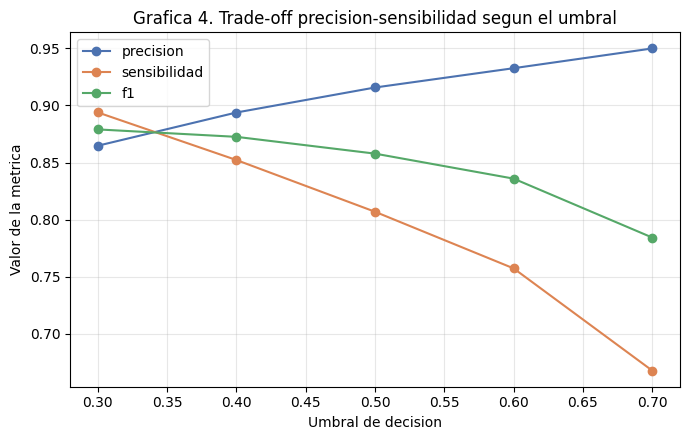

In [36]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for col, color in zip(['precision', 'sensibilidad', 'f1'], ['#4C72B0', '#DD8452', '#55A868']):
    ax.plot(tabla_umbrales.index, tabla_umbrales[col], marker='o', label=col, color=color)
ax.set_xlabel('Umbral de decision')
ax.set_ylabel('Valor de la metrica')
ax.set_title('Grafica 4. Trade-off precision-sensibilidad segun el umbral')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Se observa el trade-off esperado: al subir el umbral de 0.3 a 0.7, la **precisión sube** (el modelo se vuelve más "exigente" para etiquetar a alguien como "con prestaciones", así que cuando lo hace, acierta más seguido), pero la **sensibilidad baja** (deja escapar cada vez más personas que sí tienen prestaciones pero el modelo ya no se atreve a clasificar así).

Por eso se elige el umbral de 0.6: le da más peso a identificar a las personas sin prestaciones, sin llegar a 0.7, donde el error en la clase con prestaciones crece demasiado.

# Curva ROC y AUC

Ahora se grafica la curva ROC, que muestra el trade-off entre sensibilidad y falsos positivos en todos los umbrales posibles, junto con el AUC que ya habíamos calculado.

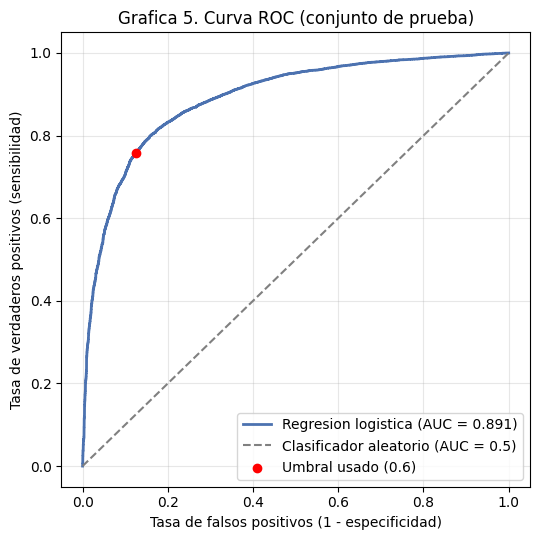

AUC: 0.8908


In [37]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds_roc = roc_curve(Y_test, probs_test)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(fpr, tpr, color='#4C72B0', linewidth=2, label=f'Regresion logistica (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador aleatorio (AUC = 0.5)')

idx = (thresholds_roc >= 0.6).sum() - 1
ax.scatter(fpr[idx], tpr[idx], color='red', zorder=5, label='Umbral usado (0.6)')

ax.set_xlabel('Tasa de falsos positivos (1 - especificidad)')
ax.set_ylabel('Tasa de verdaderos positivos (sensibilidad)')
ax.set_title('Grafica 5. Curva ROC (conjunto de prueba)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")

La curva se mantiene claramente por encima de la diagonal (que representa un clasificador que adivina al azar), con un **AUC de 0.8908**. El AUC resume el desempeño del modelo considerando *todos* los umbrales posibles a la vez, no solo el que se termine usando, y no se ve afectado por el desbalance de clases; un valor de 0.8908 (en una escala de 0.5 a 1.0) indica que el modelo tiene una **buena capacidad discriminativa**: si se toma al azar una persona con prestaciones y una sin prestaciones, el modelo le asigna una probabilidad más alta a la persona con prestaciones el 89.1% de las veces. El punto rojo marca dónde cae el umbral de 0.6 que se usa en el resto del reporte.

# Interpretación del modelo

Coeficientes y odds ratios del modelo de predicción (scikit-learn, balanceado)

Ahora vamos a sacar los coeficientes del modelo entrenado con `scikit-learn` y convertirlos a algo más fácil de interpretar: el **odds ratio** (e elevado al coeficiente), que dice cuánto se multiplican los momios de tener prestaciones por cada unidad que sube esa variable. También se calcula `cambio_pct`, que es lo mismo pero expresado como porcentaje de cambio, para no tener que hacer la resta mentalmente cada vez.

In [31]:
coefs = pd.Series(modelo.coef_[0], index=X_train.columns)
odds = np.exp(coefs)
tabla_coefs = pd.DataFrame({
    'coeficiente': coefs,
    'odds_ratio': odds,
    'cambio_pct': (odds - 1) * 100
}).sort_values('coeficiente', ascending=False)

print(f"Intercepto: {modelo.intercept_[0]:.4f}\n")
print(tabla_coefs.round(4).to_string())

Intercepto: -2.8403

             coeficiente  odds_ratio  cambio_pct
ambito2_6         2.0203      7.5406    654.0565
rama_est1_2       1.8392      6.2917    529.1672
rama_est1_3       1.6638      5.2795    427.9451
ambito2_5         1.1002      3.0048    200.4802
ambito2_7         0.6694      1.9530     95.3027
sex               0.2665      1.3054     30.5429
tue1_2            0.2517      1.2862     28.6180
e_con_5           0.1913      1.2108     21.0840
e_con_3           0.1756      1.1920     19.2015
ambito2_4         0.1277      1.1362     13.6242
ambito2_8         0.0953      1.0999      9.9940
anios_esc         0.0433      1.0442      4.4231
e_con_4           0.0406      1.0415      4.1462
e_con_2           0.0294      1.0299      2.9869
hrsocup           0.0137      1.0138      1.3840
eda               0.0090      1.0090      0.8993
ingocup           0.0001      1.0001      0.0081
e_con_6          -0.0811      0.9221     -7.7933
ur               -0.3117      0.7322    -26.7809

Cómo leer la tabla: un `odds_ratio` mayor a 1 (o `cambio_pct` positivo) significa que esa variable aumenta la probabilidad de tener prestaciones; menor a 1 (`cambio_pct` negativo) significa que la reduce. Por ejemplo, `ambito2_6` tiene un odds ratio de 7.54, es decir, trabajar en ese tipo de unidad económica multiplica los momios de tener prestaciones por 7.54 (+654%) respecto a la categoría de referencia. En el otro extremo, `ambito2_2` tiene un odds ratio de 0.15, lo que significa que reduce los momios en 84.5%. El intercepto (-2.8403) es el log-odds base cuando todas las variables valen 0 (o están en su categoría de referencia); por sí solo no se interpreta de forma directa, sirve como punto de partida para el cálculo.

Teniendo esto en cuenta en general, la tabla deja ver un patrón bastante claro: lo que más mueve la probabilidad de tener prestaciones no son las características personales de la persona, sino **dónde y en qué trabaja**. Las variables con mayor efecto, por mucho, son las de tipo de unidad económica (`ambito2`) y sector de actividad (`rama_est1`): trabajar en un establecimiento grande o en el sector secundario/terciario multiplica los momios varias veces (odds ratio de 5 a 7.5), mientras que trabajar en un micronegocio sin establecimiento fijo (`ambito2_2`) los reduce en más de 80%.

Las variables individuales (sexo, escolaridad, edad, ingreso) también tienen efecto, pero mucho más chico en comparación — la escolaridad, por ejemplo, apenas mueve los momios 4.4% por cada año adicional. Esto tiene sentido con lo que se sabe del mercado laboral mexicano: la formalidad (y con ella, las prestaciones) depende sobre todo de la estructura de la empresa donde trabajas, no tanto de quién eres. Esta lectura, basada solo en la magnitud de los coeficientes, se retoma y se confirma más adelante con las pruebas de significancia estadística (p-values), que dicen cuáles de estas asociaciones son estadísticamente sólidas y cuáles podrían deberse a variación muestral.

### Significancia estadística de los coeficientes (`statsmodels`)


Ahora se ajusta el mismo modelo, pero con `statsmodels` en vez de `scikit-learn`, sin `class_weight="balanced"`. La razón de usar un segundo modelo (y no ponderarlo) es que `scikit-learn` no calcula errores estándar ni p-values, y ponderar por clase distorsiona los errores estándar clásicos que sí calcula `statsmodels`. Este modelo se usa solo para inferencia (saber qué variables son significativas), no para predecir.

In [32]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train.astype(float))

logit_model = sm.Logit(Y_train.astype(float), X_train_sm)
logit_res = logit_model.fit(disp=0)

print(logit_res.summary())

                           Logit Regression Results                           
Dep. Variable:      TienePrestaciones   No. Observations:                71280
Model:                          Logit   Df Residuals:                    71256
Method:                           MLE   Df Model:                           23
Date:                Mon, 14 Sep 2026   Pseudo R-squ.:                  0.3840
Time:                        19:56:18   Log-Likelihood:                -27015.
converged:                       True   LL-Null:                       -43858.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -2.1060      0.090    -23.314      0.000      -2.283      -1.929
sex             0.2821      0.026     10.902      0.000       0.231       0.333
eda             0.0091      0.001      9.227    

El modelo converge sin problema (converged: True) con las 71,280 observaciones de entrenamiento y 23 variables explicativas. El pseudo-R² de McFadden es 0.384, que para un modelo logit se considera un ajuste muy bueno, y el LLR p-value de 0.000 confirma que el modelo en conjunto es significativamente mejor que uno sin ninguna variable explicativa.

Viendo la columna P>|z| (el p-value de cada coeficiente), la mayoría de las variables son significativas al 5%:
* todas las de rama_est1, ambito2_2, ambito2_3, ambito2_5, ambito2_6, ambito2_7, tue1_2, tue1_3, además de sex, eda, ur, zona, anios_esc, hrsocup, ingocup y e_con_3, e_con_5 — todas con p < 0.05.
* Las que no llegan a ser significativas son e_con_2 (p=0.223), e_con_4 (p=0.319), e_con_6 (p=0.091), ambito2_4 (p=0.053, justo en el límite) y ambito2_8 (p=0.424): para esas categorías, no hay evidencia suficiente de que su efecto sea distinto de cero, así que no se puede afirmar con confianza que difieran de su categoría de referencia.

In [34]:
params = logit_res.params
conf = logit_res.conf_int()
conf.columns = ['ci_low', 'ci_high']
pvals = logit_res.pvalues

tabla_sm = pd.DataFrame({
    'coeficiente': params,
    'error_estandar': logit_res.bse,
    'z': logit_res.tvalues,
    'p_value': pvals,
    'odds_ratio': np.exp(params),
    'or_ci_low_95': np.exp(conf['ci_low']),
    'or_ci_high_95': np.exp(conf['ci_high']),
})
tabla_sm['significativo_5pct'] = tabla_sm['p_value'] < 0.05
tabla_sm = tabla_sm.drop(index='const').sort_values('coeficiente', ascending=False)

pd.set_option('display.max_rows', None)
print(tabla_sm.round(4).to_string())

no_significativas = tabla_sm[~tabla_sm['significativo_5pct']]
print(f"Variables NO significativas al 5% ({len(no_significativas)} de {len(tabla_sm)}):")
print(no_significativas[['coeficiente','p_value']].round(4).to_string())

             coeficiente  error_estandar        z  p_value  odds_ratio  or_ci_low_95  or_ci_high_95  significativo_5pct
ambito2_6         2.0565          0.0861  23.8854   0.0000      7.8188        6.6047         9.2561                True
rama_est1_2       1.7777          0.0606  29.3246   0.0000      5.9163        5.2535         6.6627                True
rama_est1_3       1.6780          0.0591  28.4154   0.0000      5.3550        4.7697         6.0121                True
ambito2_5         1.1040          0.0657  16.7969   0.0000      3.0161        2.6516         3.4308                True
ambito2_7         0.6563          0.0949   6.9189   0.0000      1.9277        1.6006         2.3216                True
sex               0.2821          0.0259  10.9024   0.0000      1.3259        1.2603         1.3948                True
tue1_2            0.2375          0.0528   4.4957   0.0000      1.2680        1.1433         1.4063                True
e_con_3           0.2066          0.0758

**Lectura de la tabla:** de las 23 variables, 18 salen significativas al 5% y 5 no:

- `e_con_2` (unión libre vs. separado/divorciado, p=0.223)
- `e_con_4` (p=0.319)
- `e_con_6` (p=0.091)
- `ambito2_4` (p=0.053, casi en el límite)
- `ambito2_8` (p=0.424)

Que no sean significativas quiere decir que, controlando por las demás variables, no hay evidencia suficiente de que esas categorías sean distintas a su categoría de referencia (unión libre para `e_con`, ámbito agropecuario para `ambito2`). Sus odds ratios están todos muy cerca de 1 (1.06, 1.07, 0.95, 1.10 y 1.05) y sus intervalos de confianza cruzan el 1, que es justo lo que se espera cuando no hay una asociación real.

En cambio, las variables que ya se habían destacado como las más importantes sí salen significativas (p < 0.001):

- Tipo de unidad económica: `ambito2_6`, `ambito2_5`, `ambito2_2`, `ambito2_3`
- Sector de actividad: `rama_est1_2`, `rama_est1_3`
- Tipo de empleador: `tue1_3`
- Escolaridad, ingreso, sexo, zona y área rural/urbana

O sea que la interpretación que ya se había hecho con los coeficientes de `scikit-learn` sí se sostiene con evidencia estadística.

**Comparación entre el modelo balanceado y el no ponderado:** antes de confiar en estos p-values para interpretar el modelo balanceado, hay que checar que los dos modelos digan más o menos lo mismo.

In [35]:
coefs_sklearn = pd.Series(modelo.coef_[0], index=X_train.columns)
comparativa = pd.DataFrame({
    'coef_sklearn_balanceado': coefs_sklearn,
    'coef_statsmodels_sin_ponderar': params.drop('const')
})
comparativa['mismo_signo'] = np.sign(comparativa['coef_sklearn_balanceado']) == np.sign(comparativa['coef_statsmodels_sin_ponderar'])
print(comparativa.round(4).to_string())
print(f"\nCoinciden en signo: {comparativa['mismo_signo'].sum()} de {len(comparativa)} variables")

             coef_sklearn_balanceado  coef_statsmodels_sin_ponderar  mismo_signo
sex                           0.2665                         0.2821         True
eda                           0.0090                         0.0091         True
ur                           -0.3117                        -0.3024         True
zona                         -0.4618                        -0.4591         True
anios_esc                     0.0433                         0.0393         True
hrsocup                       0.0137                         0.0126         True
ingocup                       0.0001                         0.0001         True
e_con_2                       0.0294                         0.0578         True
e_con_3                       0.1756                         0.2066         True
e_con_4                       0.0406                         0.0711         True
e_con_5                       0.1913                         0.1784         True
e_con_6                     

Los 23 coeficientes coinciden en signo entre el modelo balanceado y el no ponderado, y sus magnitudes son parecidas. Esto confirma lo que ya se había dicho en la metodología: `class_weight="balanced"` cambia sobre todo qué tan alta o baja predice la probabilidad el modelo (y por lo tanto dónde cae el umbral), pero no cambia la dirección ni la importancia relativa de las variables. Por eso se puede usar los p-values del modelo no ponderado como guía confiable de qué asociaciones del modelo balanceado son reales y cuáles podrían ser solo ruido.

## Variables con mayor efecto positivo

El tipo de unidad económica y el sector de actividad son lo que más pesa en el modelo. Trabajar en un establecimiento grande (`ambito2_6`) multiplica los momios de tener prestaciones por 7.5, y uno mediano (`ambito2_5`) por 3.0. Trabajar en el sector secundario (`rama_est1_2`, industria) o terciario (`rama_est1_3`, servicios y comercio) también sube los momios varias veces frente al sector primario. Tiene sentido: el campo es el sector con más informalidad, y las empresas grandes casi siempre operan de forma formal.

Entre las variables numéricas, cada año de escolaridad sube los momios 4.4%, y cada 1,000 pesos de ingreso los sube 8.4%.

Un dato para mencionar con cuidado: ser mujer se asocia con +30.6% en los momios, pero esto no significa que "ser mujer" cause tener prestaciones — más bien, dentro de esta población las mujeres se concentran más en sectores con más formalidad (servicios, educación, salud), así que es un efecto de composición, no un efecto directo del sexo.

De las categorías de estado civil, solo `e_con_3` y `e_con_5` resultan significativas, con efectos positivos moderados; el resto no muestra diferencia real contra la categoría de referencia.

## Variables con mayor efecto negativo

En el otro extremo, trabajar en un micronegocio sin establecimiento fijo (`ambito2_2`) reduce los momios en 84.5%, y trabajar en el sector informal y hogares (`tue1_3`, incluye trabajo doméstico) los reduce en 75.6%. Vivir en zona rural reduce los momios 26.8%, y vivir fuera de la frontera norte los reduce 37.0%.

Estas son justo las variables que más ayudan a identificar a alguien con probabilidad alta de no tener prestaciones — que es el caso que el modelo prioriza detectar con el umbral de 0.6: entre más de estas condiciones tenga una persona (trabajar en un micronegocio, en el sector informal, en zona rural), más probable es que el modelo la clasifique como "sin prestaciones", que es justo a quien se quiere identificar mejor.

`ambito2_4` queda justo en el límite de significancia (p=0.053), así que no se puede afirmar con confianza que tenga un efecto real.

## Coherencia con la problemática original

En conjunto, el patrón tiene sentido: las variables centrales (sector, tamaño de la unidad económica, escolaridad, ingreso, zona) son significativas y no hay señales de multicolinealidad entre ellas. Esto respalda tanto la interpretación de los coeficientes como la decisión de usar el umbral de 0.6, el modelo identifica de forma consistente que la informalidad depende sobre todo de dónde y en qué trabaja la persona, no de sus características individuales, y ese es justo el tipo de patrón que interesa capturar bien al priorizar detectar a la gente sin prestaciones.

# Reflexión y Conclusiones

El objetivo de este reporte era construir un modelo de clasificación para predecir si una persona empleada cuenta con prestaciones laborales, usando regresión logística, y evaluarlo de su capacidad predictiva y la validez estadistica de su interpretación

**Sobre la definición del problema.** No fue necesario construir artificialmente una variable cualitativa: la ENOE ya trae una variable de interés genuina (`pre_asa`), aunque tal como viene codificada mezcla categorías que no aplican con las dos que sí interesan. Delimitar la población a personas subordinadas y remuneradas, y descartar del conjunto de variables explicativas a las que resultaron ser casi una copia de la variable de respuesta (`emp_ppal`, `seg_soc`, `imssissste`, `p6d`, `niv_ins`), fue necesario para que el problema de clasificación tuviera sentido y no fuera trivial.

**Sobre la partición de los datos.** El balance de clases se conservó de forma prácticamente idéntica en el conjunto original, entrenamiento y prueba (69.47% / 30.53%), y la prueba ji-cuadrada lo confirmó con evidencia formal (p-value = 1.0000), no solo con inspección visual de una tabla. Esto importa porque, como se ve más adelante, permite comparar directamente las métricas de validación cruzada contra las de prueba sin preocuparse de que un desajuste en el balance esté distorsionando la comparación.

**Sobre el modelo predictivo.** La validación cruzada de 7 folds dio una estimación estable del desempeño (desviación estándar entre 0.0011 y 0.0019 en todas las métricas), con una exactitud promedio de 81.6% y un AUC de 0.89. Al evaluar el modelo final sobre el conjunto de prueba con el umbral por default (0.5), las métricas salieron prácticamente idénticas a las de validación cruzada, lo que confirma que el modelo generaliza bien y no está sobreajustado a una partición particular.

**Sobre la elección del umbral.** Se optó por subir el umbral de decisión a 0.6 en vez de dejarlo en 0.5, priorizando detectar correctamente a las personas sin prestaciones por encima de las que sí las tienen. La razón es de fondo, no solo estadística: para un uso real de este modelo (identificar informalidad laboral en México), es más útil no dejar pasar a alguien sin prestaciones que ser igual de preciso con quienes sí las tienen. Esto trajo el costo esperado —la sensibilidad para "con prestaciones" bajó de 81.3% a 75.7%, y la exactitud general bajó de 81.4% a 79.3%— pero el AUC se mantuvo prácticamente igual (0.8905 en validación cruzada vs. 0.8908 en prueba), lo que confirma que ese cambio en las métricas fue una decisión deliberada sobre dónde poner el punto de corte, y no un problema de que el modelo generalizara peor de lo esperado.

**Sobre la interpretación y su validez estadística.** El modelo de inferencia (`statsmodels`, sin ponderar) mostró que 18 de las 23 variables son estadísticamente significativas al 5%, incluyendo todas las que sostienen el argumento central del reporte (sector de actividad, tamaño de la unidad económica, escolaridad, ingreso, sexo y zona geográfica), con un pseudo-R² de McFadden de 0.384. La comparación de signos entre el modelo balanceado (usado para predecir) y el modelo sin ponderar (usado para inferencia) mostró coincidencia total en las 23 variables, lo que da confianza en que el balanceo de clases no distorsiona la dirección de las asociaciones, solo la calibración de las probabilidades. Las variables que resultaron más relevantes en magnitud —tipo de unidad económica y sector de actividad, por mucho las de mayor efecto— son justamente las que mejor ayudan a identificar a alguien sin prestaciones, que es el tipo de error que el modelo prioriza evitar con el umbral de 0.6.

En conjunto, el patrón que emerge es coherente de principio a fin: las prestaciones laborales no dependen tanto de quién es la persona, sino de dónde y en qué trabaja, y esa es la variable que el modelo aprovecha mejor tanto para predecir como para explicar.

# Referencias

- INEGI (2026). *Encuesta Nacional de Ocupación y Empleo (ENOE), primer trimestre de 2026*. Microdatos. Instituto Nacional de Estadística y Geografía. https://www.inegi.org.mx/programas/enoe/15ymas/
- INEGI. *Encuesta Nacional de Ocupación y Empleo. Diccionario de datos, SDEMT225*. https://www.inegi.org.mx/rnm/index.php/catalog/1121/data-dictionary/F42?file_name=SDEMT225
- INEGI. *Conociendo la base de datos de la ENOE* (descripción de las variables `ambito2` y `tue1`). https://www.inegi.org.mx/contenidos/productos/prod_serv/contenidos/espanol/bvinegi/productos/metodologias/est/702825001357.pdf